In [25]:
import numpy as np
import pandas as pd

# 固定亂數種子
rng = np.random.default_rng(42)

n = 100

# 三個自變數都服從常態分佈
x1 = rng.normal(0, 1, n)
x2 = rng.normal(0, 1, n)
x3 = rng.normal(0, 1, n)

# 誤差項
epsilon = rng.normal(0, 1, n)

# 建立 y
y = 0.2*x1 + 1.5*x2 + 0.8*x3 + epsilon

df = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "x3": x3,
    "y": y
})

print(df.head())

         x1        x2        x3         y
0  0.304717 -0.378163  0.337575  1.491109
1 -1.039984  1.299228  1.407482  1.332970
2  0.750451 -0.356264  0.090585  0.551990
3  0.940565  0.737516  0.643939  1.481012
4 -1.951035 -0.933618 -2.050172 -3.492096


In [26]:
print(df.corr().round(2))

      x1    x2    x3     y
x1  1.00  0.09 -0.01  0.19
x2  0.09  1.00  0.01  0.73
x3 -0.01  0.01  1.00  0.43
y   0.19  0.73  0.43  1.00


In [27]:
# min-max scaling 
def gray_embedding(x):
    result = []
    max = x.max()
    min = x.min()
    for i in range(len(x)):
        z = ((x[i]-min)/(max-min))*255
        result.append(z)
    return result

In [28]:
X1 = gray_embedding(df["x1"])
X2 = gray_embedding(df["x2"])
X3 = gray_embedding(df["x3"])

df_gray = pd.DataFrame({
    "X1":X1,
    "X2":X2,
    "X3":X3,
    "Y":y
})

# y從大排到小
df_gray = df_gray.sort_values("Y", ascending=False).reset_index(drop=True)

df_gray


,X1,X2,X3,Y
0,162.097863,255.000000,94.940954,4.686122
1,131.702366,215.309400,130.434396,4.410815
2,176.294826,188.692556,112.414072,3.444338
3,81.755694,197.089163,155.840962,3.378867
4,70.191431,208.651847,70.102607,3.135581
...,...,...,...,...
95,181.891681,47.862764,55.539969,-2.831205
96,191.903929,56.421777,89.129206,-3.037451
97,0.000000,60.563777,24.069923,-3.492096
98,135.187503,86.754581,59.616503,-3.672475


In [29]:
# 做完embedding完後，相關性沒有改變
print(df_gray.corr().round(2))

      X1    X2    X3     Y
X1  1.00  0.09 -0.01  0.19
X2  0.09  1.00  0.01  0.73
X3 -0.01  0.01  1.00  0.43
Y   0.19  0.73  0.43  1.00


In [30]:
# 根據變數與Y之間的相關性排序
corr = df_gray.corr(numeric_only=True)["Y"].drop("Y").abs()

order = corr.sort_values(ascending=False).index

df_gray = df_gray[ list(order) + ["Y"] ]

df_gray

,X2,X3,X1,Y
0,255.000000,94.940954,162.097863,4.686122
1,215.309400,130.434396,131.702366,4.410815
2,188.692556,112.414072,176.294826,3.444338
3,197.089163,155.840962,81.755694,3.378867
4,208.651847,70.102607,70.191431,3.135581
...,...,...,...,...
95,47.862764,55.539969,181.891681,-2.831205
96,56.421777,89.129206,191.903929,-3.037451
97,60.563777,24.069923,0.000000,-3.492096
98,86.754581,59.616503,135.187503,-3.672475


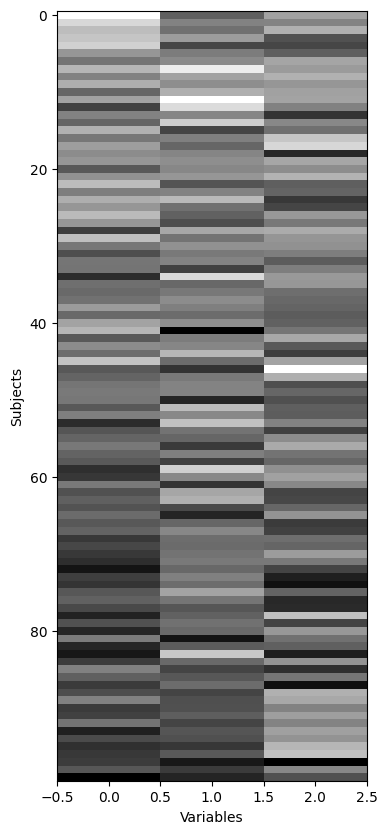

In [31]:
import matplotlib.pyplot as plt

image = df_gray.iloc[:,:-1].values

plt.figure(figsize=(4,10))

plt.imshow(
    image,
    cmap="gray",
    aspect="auto",
    vmin=0,
    vmax=255
)

plt.xlabel("Variables")
plt.ylabel("Subjects")

plt.show()

In [32]:
# 自變數
X = df_gray[["X1", "X2", "X3"]]

# 加入截距項
X = sm.add_constant(X)

# 建立模型
model = sm.OLS(df_gray["Y"], X).fit()

# 查看結果
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     81.29
Date:                  週日, 12 七月 2026   Prob (F-statistic):           2.97e-26
Time:                        10:03:27   Log-Likelihood:                -141.41
No. Observations:                 100   AIC:                             290.8
Df Residuals:                      96   BIC:                             301.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3814      0.417    -12.905      0.0

In [37]:
# 自變數
x = df[["x1", "x2", "x3"]]

# 加入截距項
x = sm.add_constant(x)

# 建立模型
model_origin = sm.OLS(df["y"], x).fit()

# 查看結果
print(model_origin.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     81.29
Date:                  週日, 12 七月 2026   Prob (F-statistic):           2.97e-26
Time:                        10:08:14   Log-Likelihood:                -141.41
No. Observations:                 100   AIC:                             290.8
Df Residuals:                      96   BIC:                             301.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1047      0.102      1.027      0.3

In [10]:
#存檔
df.to_csv("simulation_origin_data.csv", index=False)

In [35]:
df_gray = df_gray.merge(
    df[["y", "x1", "x2", "x3"]].rename(columns={
        "x1": "raw_x1",
        "x2": "raw_x2",
        "x3": "raw_x3"
    }),
    left_on="Y",
    right_on="y",
    how="left"
).drop(columns="y")

df_gray

,X2,X3,X1,Y,raw_x1,raw_x2,raw_x3
0,255.000000,94.940954,162.097863,4.686122,0.650593,2.913862,-0.529439
1,215.309400,130.434396,131.702366,4.410815,0.162753,2.128470,0.232170
2,188.692556,112.414072,176.294826,3.444338,0.878450,1.601779,-0.154506
3,197.089163,155.840962,81.755694,3.378867,-0.638878,1.767930,0.777338
4,208.651847,70.102607,70.191431,3.135581,-0.824481,1.996731,-1.062414
...,...,...,...,...,...,...,...
95,47.862764,55.539969,181.891681,-2.831205,0.968278,-1.184944,-1.374896
96,56.421777,89.129206,191.903929,-3.037451,1.128972,-1.015579,-0.654146
97,60.563777,24.069923,0.000000,-3.492096,-1.951035,-0.933618,-2.050172
98,86.754581,59.616503,135.187503,-3.672475,0.218689,-0.415357,-1.287423


In [36]:
df_gray.to_csv("embedding_data.csv", index=False)